In [5]:
"""
LightGBM Binary Classifier
- Hyperparameter tuning với Optuna TPE (metric: Gini trên valid set)
- Fit lại trên full train với best params
- Dự đoán test set, tính Gini + SHAP
"""

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 0. Config ──────────────────────────────────────────────────────────────────
DATA_PATH   = "master_data_train_test_split.csv"
ID_COL      = "SK_ID_CURR"
TARGET_COL  = "TARGET"
DATASET_COL = "flag_train_test"          # giá trị: "train" / "test"
FT_PATH     = r"D:\KL-lieuvth2\feature_shortlist.csv"
VALID_SIZE  = 0.30               # 70 / 30
RANDOM_SEED = 42
N_TRIALS    = 30                # số lần Optuna thử


In [6]:

# ── 1. Load data ───────────────────────────────────────────────────────────────
print("=" * 60)
print("1. Loading data …")
df = pd.read_csv(DATA_PATH).iloc[:, 1:]
print(f"   Shape: {df.shape}")
print(f"   dataset counts:\n{df[DATASET_COL].value_counts()}")

# ── 2. Split train / test ──────────────────────────────────────────────────────
train_df = df[df[DATASET_COL] == "train"].copy()
test_df  = df[df[DATASET_COL] == "test"].copy()

drop_cols = [ID_COL, TARGET_COL, DATASET_COL]

# Read selected features from FT_PATH
feature_list = pd.read_csv(FT_PATH)["feature"].dropna().astype(str).tolist()

# Chỉ giữ các feature thực sự tồn tại trong df
feature_cols = [c for c in feature_list if c in df.columns]

# Kiểm tra feature trong file nhưng không có trong df
missing_features = [c for c in feature_list if c not in df.columns]

print(f"\n2. Features selected from FT_PATH: {len(feature_cols)}")
print(f"   First 5 features: {feature_cols[:5]}")

if missing_features:
    print(f"   Warning: {len(missing_features)} features not found in df")
    print(f"   Missing: {missing_features[:10]}")

# Chỉ lấy các cột cần thiết
train_df = train_df[[ID_COL, TARGET_COL] + feature_cols].copy()
test_df  = test_df[[ID_COL, TARGET_COL] + feature_cols].copy()

# ── 3. Convert object → categorical ───────────────────────────────────────────
print("\n3. Converting object columns to categorical …")
for col in feature_cols:
    if df[col].dtype == "object":
        train_df[col] = train_df[col].astype("category")
        test_df[col]  = test_df[col].astype("category")
        print(f"   → {col}")

X_all   = train_df[feature_cols]
y_all   = train_df[TARGET_COL]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET_COL] if TARGET_COL in test_df.columns else None


1. Loading data …
   Shape: (307511, 259)
   dataset counts:
flag_train_test
train    215257
test      92254
Name: count, dtype: int64

2. Features selected from FT_PATH: 76
   First 5 features: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EMPLOY_YEARS', 'BUREAU_DEBT_CREDIT_RATIO', 'AMT_GOODS_PRICE']

3. Converting object columns to categorical …
   → ORGANIZATION_TYPE_GROUPED
   → NAME_INCOME_TYPE
   → NAME_EDUCATION_TYPE
   → NAME_FAMILY_STATUS
   → NAME_HOUSING_TYPE
   → NAME_CONTRACT_TYPE


In [7]:

# ── 4. Train / Valid split ─────────────────────────────────────────────────────
print("\n4. Splitting train → train_sub / valid (70 / 30) …")
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all,
    test_size=VALID_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_all,
)
print(f"   train_sub: {X_train.shape}, valid: {X_valid.shape}")

dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain, free_raw_data=False)

def gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1



4. Splitting train → train_sub / valid (70 / 30) …
   train_sub: (150679, 76), valid: (64578, 76)


In [8]:
import optuna
import lightgbm as lgb

print("\n5. Optuna TPE tuning (Full Param Logging) …")

def objective(trial: optuna.Trial) -> float:
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": RANDOM_SEED,
        
        # --- Tune n_estimators & learning_rate đồng thời ---
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        
        # --- Cấu trúc cây (Siết chặt chống Overfit) ---
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 1000, 5000),
        
        # --- Sampling & Regularization ---
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.7),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 50.0, log=True),
    }

    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        callbacks=[lgb.log_evaluation(period=-1)],
    )

    preds = model.predict(X_valid)
    trial_gini = gini(y_valid, preds)

    # --- IN ĐẦY ĐỦ TẤT CẢ THAM SỐ VÀO LOG ---
    try:
        best_so_far = study.best_value
    except (ValueError, NameError):
        best_so_far = trial_gini

    # Format từng cặp key=value thành chuỗi ngắn gọn
    param_str = " | ".join([f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in params.items()])
    
    print(
        f"Trial {trial.number:>3d} | "
        f"Gini Valid: {trial_gini:.6f} | "
        f"Best Valid: {best_so_far:.6f}\n"
        f"   └─ Params: {param_str}\n"
    )

    return trial_gini

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print(f"\n   ✓ Best Gini (valid): {study.best_value:.6f}")
print(f"   Best params: {study.best_params}")


5. Optuna TPE tuning (Full Param Logging) …
Trial   0 | Gini Valid: 0.557198 | Best Valid: 0.557198
   └─ Params: objective=binary | metric=auc | verbosity=-1 | boosting_type=gbdt | random_state=42 | n_estimators=1062 | learning_rate=0.0722 | max_depth=5 | num_leaves=44 | min_child_samples=1624 | subsample=0.6468 | colsample_bytree=0.3232 | reg_lambda=29.6215

Trial   1 | Gini Valid: 0.555887 | Best Valid: 0.557198
   └─ Params: objective=binary | metric=auc | verbosity=-1 | boosting_type=gbdt | random_state=42 | n_estimators=1402 | learning_rate=0.0436 | max_depth=3 | num_leaves=62 | min_child_samples=4330 | subsample=0.6637 | colsample_bytree=0.3727 | reg_lambda=2.0493

Trial   2 | Gini Valid: 0.552069 | Best Valid: 0.557198
   └─ Params: objective=binary | metric=auc | verbosity=-1 | boosting_type=gbdt | random_state=42 | n_estimators=956 | learning_rate=0.0298 | max_depth=4 | num_leaves=29 | min_child_samples=3448 | subsample=0.6418 | colsample_bytree=0.4169 | reg_lambda=4.1922

T

In [9]:
# ── 6. Fit mô hình trên full train với best params ────────────────────────────
print("\n6. Re-fitting on full train set …")

# Tạo dict tham số hoàn chỉnh
final_params = {
    "objective":     "binary",
    "metric":        "auc",
    "verbosity":     -1,
    "boosting_type": "gbdt",
    "random_state":  RANDOM_SEED,
    **study.best_params,
}

# 1. Tách n_estimators ra khỏi final_params để làm num_boost_round
# Lấy trực tiếp từ best_params để đảm bảo không bị sai lệch
n_estimators = final_params.pop("n_estimators", None)

if n_estimators is None:
    raise ValueError("Không tìm thấy 'n_estimators' trong study.best_params!")

# 2. Tạo Dataset cho tập full train
dall = lgb.Dataset(X_all, label=y_all, free_raw_data=False)

# 3. Fit mô hình trên full train (Không Early Stopping)
final_model = lgb.train(
    final_params,
    dall,
    num_boost_round=n_estimators,
    valid_sets=[dall],  # Truyền dall vào valid_sets chỉ để hiển thị log AUC khi train
    callbacks=[lgb.log_evaluation(period=100)], # In log mỗi 100 cây
)

print(f"\n   ✓ Hoàn tất Re-fit với {n_estimators} cây trên full train set!")


6. Re-fitting on full train set …
[100]	training's auc: 0.765654
[200]	training's auc: 0.779674
[300]	training's auc: 0.787093
[400]	training's auc: 0.792196
[500]	training's auc: 0.796451
[600]	training's auc: 0.800496
[700]	training's auc: 0.804216
[800]	training's auc: 0.807574
[900]	training's auc: 0.81057
[1000]	training's auc: 0.813396
[1100]	training's auc: 0.816047
[1200]	training's auc: 0.81852
[1300]	training's auc: 0.820635
[1400]	training's auc: 0.822835
[1500]	training's auc: 0.824645

   ✓ Hoàn tất Re-fit với 1578 cây trên full train set!


In [10]:
# ── Predict trên full train set (sau khi refit) ────────────────────────────────
y_pred_train = final_model.predict(X_all)
train_auc    = roc_auc_score(y_all, y_pred_train)
train_gini   = 2 * train_auc - 1
print(f"Train AUC  : {train_auc:.6f}")
print(f"Train Gini : {train_gini:.6f}")

Train AUC  : 0.826234
Train Gini : 0.652469


In [11]:

# ── 7. Dự đoán trên test set + Gini ───────────────────────────────────────────
print("\n7. Predicting on test set …")
y_pred_test = final_model.predict(X_test)

if y_test is not None and y_test.notna().all():
    test_gini = gini(y_test, y_pred_test)
    test_auc  = roc_auc_score(y_test, y_pred_test)
    print(f"   Test AUC  : {test_auc:.6f}")
    print(f"   Test Gini : {test_gini:.6f}")
else:
    print("   (Test labels không có sẵn – bỏ qua tính Gini trên test)")

# Lưu predictions
test_df = test_df.copy()
test_df["PRED_PROBA"] = y_pred_test
test_df[[ID_COL, "PRED_PROBA"]].to_csv("test_predictions.csv", index=False)
print("   Saved → test_predictions.csv")



7. Predicting on test set …
   Test AUC  : 0.781448
   Test Gini : 0.562896
   Saved → test_predictions.csv


In [12]:
import pickle

with open("lgbm_model.pkl", "wb") as f:
    pickle.dump(final_model, f)
print("Saved → lgbm_model.pkl")

Saved → lgbm_model.pkl



8. Computing SHAP values …
   Saved → shap_summary_bar.png
   Saved → shap_summary_beeswarm.png
   Saved → shap_importance.csv

Top 10 features by SHAP:
                 feature  mean_abs_shap
            EXT_SOURCE_2       0.310348
            EXT_SOURCE_3       0.255451
             CREDIT_TERM       0.146008
           INST_PCT_LATE       0.120162
            EMPLOY_YEARS       0.107971
             AMT_ANNUITY       0.107353
      GOODS_CREDIT_RATIO       0.106963
     NAME_EDUCATION_TYPE       0.105805
   PREV_CNT_PAYMENT_MEAN       0.103136
BUREAU_DEBT_CREDIT_RATIO       0.101409

   Saved → optuna_analysis.png

Done!


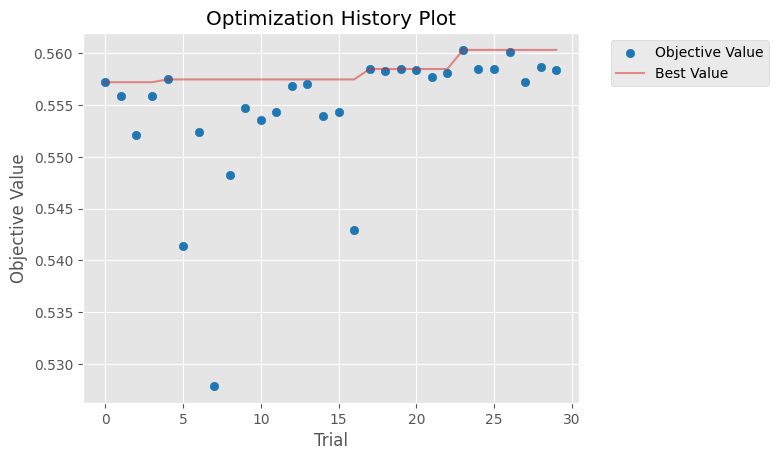

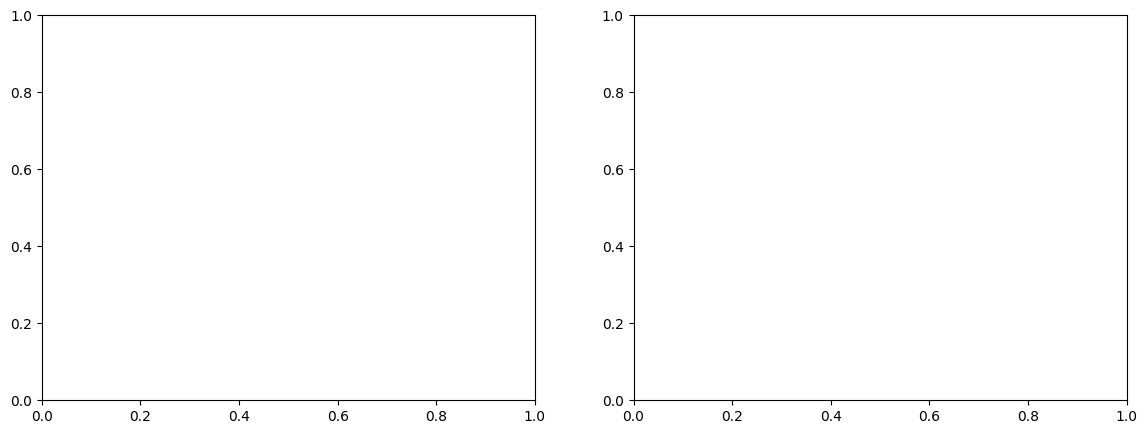

In [13]:

# ── 8. SHAP values ────────────────────────────────────────────────────────────
print("\n8. Computing SHAP values …")

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# — 8a. Summary plot (bar)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False,
                  max_display=20)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.close()
print("   Saved → shap_summary_bar.png")

# — 8b. Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.close()
print("   Saved → shap_summary_beeswarm.png")

# — 8c. Lưu mean |SHAP| per feature
shap_df = pd.DataFrame({
    "feature":        feature_cols,
    "mean_abs_shap":  np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_df.to_csv("shap_importance.csv", index=False)
print("   Saved → shap_importance.csv")
print("\nTop 10 features by SHAP:")
print(shap_df.head(10).to_string(index=False))

# ── 9. Optuna visualisation (optional) ────────────────────────────────────────
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.sca(axes[0]); plot_optimization_history(study)
    plt.sca(axes[1]); plot_param_importances(study)
    plt.tight_layout()
    plt.savefig("optuna_analysis.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("\n   Saved → optuna_analysis.png")
except Exception:
    pass

print("\n" + "=" * 60)
print("Done!")